# Notebook For Figure 4

### TODOs

- [ ] Panel Why n= 21. It should be like Figure 3, n=19. Make sure we have the same mice everywhere
- [ ] Panel C. Carefull the index of run is crossed by a trace
- [ ] Panel D. Legend. indicate mouse 1. No need maybe to show mouse 2

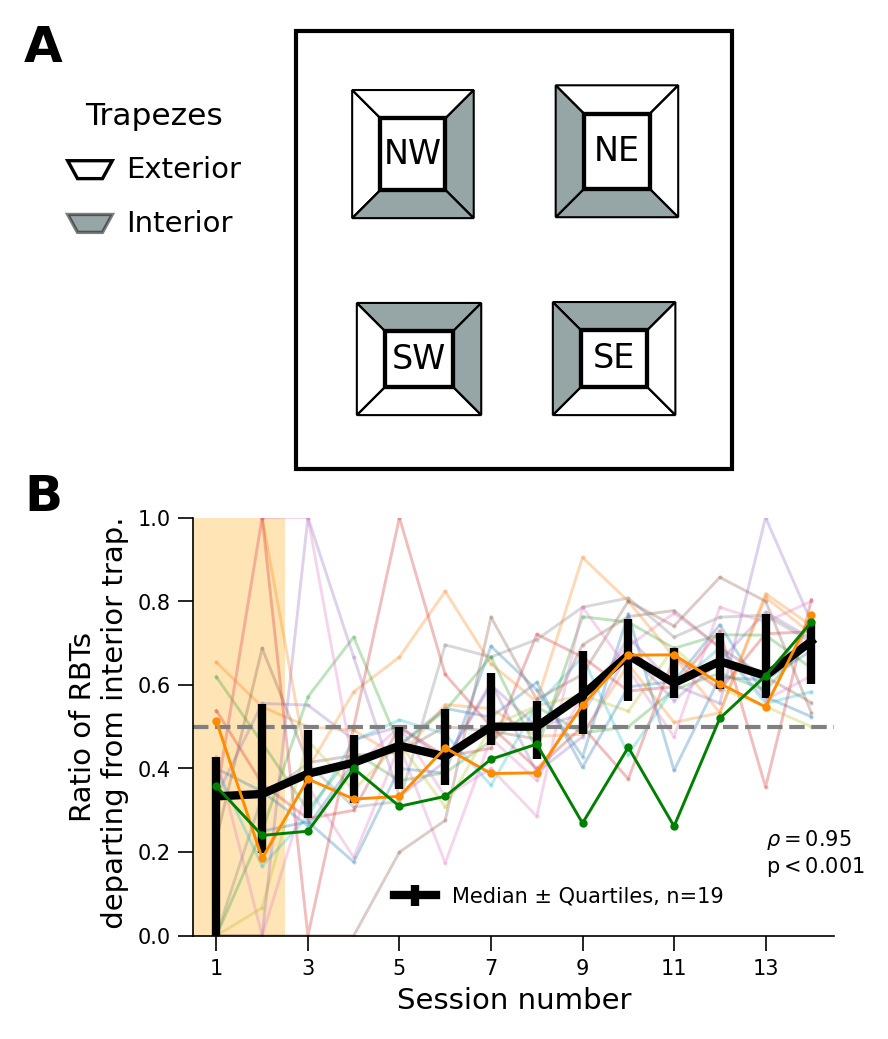

In [1]:
from IPython.display import display
from PIL import Image

# Load and display the image
img = Image.open("FigureS03.png")
display(img)

# 1. Imports necessary libraries and functions

In [2]:
import os
from processing_TowerCoordinates import *
from processing_session_trajectory import *
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize
import matplotlib.patches as patches
from matplotlib.patches import Polygon
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
import pickle
import scipy.ndimage as ndimage
import warnings 
from matplotlib.colors import LinearSegmentedColormap
from bisect import bisect
from scipy.stats import spearmanr

plt.style.use('paper.mplstyle')

# Setting the seed for random processes
seed = 27
np.random.seed(seed)

#useful for interrupting Run All:
#raise SystemExit("Stopping execution here.")



In [3]:
plotintermediatesteps = False 

# 2. Select mice that will be analysed in the figure
### Define the data_folder where your MOU* folders are, enter the list of mice (MOU* folders), define the sessions that will be used for each animals

In [4]:
# defining data folder path and mice list

# path_to_data_folder is the path of the folder where you store the folders of your different mice.

# path_to_data_folder='/LocalData/ForagingMice/4TowersTaskMethodPaper_Data/Group1Data/'
# path_to_data_folder = '/Users/davidrobbe/Documents/Science/Data/ForagingMice/Group1Data/'
# path_to_data_folder='/home/david/MyLocalData/4TowersTask_MethodPaper/Group1Data'
path_to_data_folder = '/media/david/Maud_T5/Thesis/HarddriveDatas/Aurelien'

# Analysing the entire group of mice
mice_to_analyse = [
    "MOUEml1_5", "MOUEml1_8", "MOUEml1_11", "MOUEml1_12", "MOUEml1_13", "MOUEml1_15", "MOUEml1_18", "MOUEml1_20",
    "MOURhoA_2", "MOURhoA_5", "MOURhoA_6", "MOURhoA_8", "MOURhoA_9", "MOURhoA_12", "MOURhoA_14",
    "MOUB6NN_4", "MOUB6NN_6", "MOUB6NN_13", "MOUB6NN_15"
]

# Verify that all folders in mice_to_analyse are present in path_to_data_folder
missing_folders = [mouse for mouse in mice_to_analyse if not os.path.isdir(os.path.join(path_to_data_folder, mouse))]

if missing_folders:
    print("Missing mice folders:", missing_folders)
else:
    print("All mice folders are present in data folder.")

# Print the number of mice, the list of mice
print(f' {len(mice_to_analyse)} {"mice" if len(mice_to_analyse) > 1 else "mouse"} will be analysed\n')

# Select the number of sessions that will be analysed for each mice knowing the analysis starts with the first session (familiarisation)
first_and_last_session_indexes = [0,14]
# Select the number of sessions that will be in statistics
first_and_last_session_indexes_stats = [1,14]
# Setting the seed for random processes used in statistics
seed = 27
np.random.seed(seed)

# Select the offset to apply to the number of the sessions when plotting. By default, it is equal to the number of the first session.
# It resulsts in sessions being named respectively to their actual positions in the data set.
session_index_offset = first_and_last_session_indexes[0]


All mice folders are present in data folder.
 19 mice will be analysed



In [5]:
# Chose mice that will highlighted in statistics
illustration_mice = ['MOUEml1_8', 'MOUEml1_5']

# Chose the color with which the illustration mice will highlighted with
illustration_colors = ['darkorange', 'green']

# Set the limits of the x-axis on the statistics plots
xlim_stats = [first_and_last_session_indexes[0]+0.5,first_and_last_session_indexes[1]+0.5]


# 3. Select sessions to be analysed

In [6]:
# Mouse from which data will be used to generate the plot 
example_mouse_index = 0
example_mouse = illustration_mice[example_mouse_index]

# Chosing index of the sessions to show as examples. They are chosen by their index in the list of sessions selected with start_session_index and end_session_index
illustration_sessions_indexes = [0, 5, 12] 


# 4. General of functions

In [7]:
def force_aspect(ax, ratio=1):
    """
    Force the aspect ratio of the given axis (ax) to a specific ratio.
    The ratio parameter allows scaling of the aspect ratio. Default is 1.
    
    Arguments:
        ax (matplotlib.axes.Axes): Matplotlib axis object for plotting.
        ratio (float, optional): Ratio of the figure's dimensions
    
    """
    
    ratio = 1.0  # Set ratio to 1.0, making the aspect ratio 1:1 by default
    
    # Get the current limits of the x and y axes
    x_left, x_right = ax.get_xlim()  # Get the left and right x-axis limits
    y_low, y_high = ax.get_ylim()    # Get the lower and upper y-axis limits
    
    # Calculate the new aspect ratio and set it
    # The formula is the absolute ratio of the width and height, adjusted by the given ratio
    ax.set_aspect(abs((x_right - x_left) / (y_low - y_high)) * ratio)

def plot_learning_curves(mouse_metric_persession, ax, mice_list=None, mice_to_highlight=[], mice_to_highlight_labels=[None,None], highlight_colors = ["darkorange", "green"], show_individual_mice=True,
                         median_color='black', show_xlabel=True, ylabel='', main_line_label=None, show_fam=False, 
                         tick_interval=1, index_offset=0, xlim=[None,None], ylim=None, show_legend=True, legend_loc=(0.05, 0.9)):
    """
    Plots a given metric across sessions for multiple mice (also called a learning curves).

    Arguments:
        mouse_metric_persession (dict): Dictionary where keys are mouse IDs and values are lists of (session_index, value) lists.
        mice_list (list, optional): List of mice to include in the plot. Defaults to all mice in the mouse_metric_persession.
        mice_to_highlight (list, optional): List of up to two mice IDs to highlight with distinct colors.
        mice_to_highlight_labels (list, optional): List of the label of the mice to highlight.
        show_individual_mice (bool): If true, plot a line for each individual mouse.
        ax (matplotlib.axes.Axes): Axes object for plotting.
        show_xlabel (bool, optional): Whether to display the x-axis label. Defaults to True.
        ylabel (str, optional): Label for the y-axis.
        main_line_label (str, optional): Label of the median and quartiles range.
        show_fam (bool): Toggle the display of familiarization sessions label
        tick_interval (int, optional): Interval for x-axis tick marks. Defaults to 1.
        index_offset (int, optional): Offset to apply to the numbers in the x axis. Use it if you want to the first sessions to be named '1'.
        xlim (tuple, optional): Tuple specifying x-axis limits. Defaults to None.
        ylim (tuple, optional): Tuple specifying y-axis limits. Defaults to None.
        show_legend (bool, optional): Whether to show the legend. Defaults to True.
        legend_loc (tupple, optional): Location of the legend.
    """

    # If no mice are specified, use all available mice
    if mice_list is None:
        mice_list = list(mouse_metric_persession.keys())

    all_session_indices = set()  # Track all session indices across selected mice
    values_per_session = {}  # Store values for each session across mice

    mice_to_plot = copy.deepcopy(mice_list)

    # Ensure that the mice to hihlight will be plotted and displayed on the legend in order
    if len(mice_to_highlight)>0:

        mice_to_plot.remove(mice_to_highlight[0])
        mice_to_plot.remove(mice_to_highlight[1])

        mice_to_plot = mice_to_highlight + mice_to_plot
    
    # Loop through each mouse and gather session data

    for mouse in mice_to_plot:

        if mouse not in mouse_metric_persession:
            print(f"Mouse {mouse} not found in data. Skipping.")
            continue    

        # Selecting the sub-list of sessions to analyse
        sessions = mouse_metric_persession[mouse]

        # Extract session indices and corresponding values
        session_indices = [session[0] for session in sessions]
        values = [session[1] for session in sessions]

        # Check if there is a nan value in the values list and remove it to allow plotting of lines between points with values
        if sum(np.isnan(x) for x in values)>0:

            session_indices_array=np.array(session_indices)
            values_array=np.array(values)
            mask = ~np.isnan(values_array)
            session_indices=session_indices_array[mask]
            values=values_array[mask]

        # Plot learning curves for each mouse if show_individual_mice is True
        if show_individual_mice:

            if mouse == mice_to_highlight[0]:
                color = highlight_colors[0]
                ax.plot(np.array(session_indices)+index_offset, values, color=color, marker='o', linewidth=0.7, 
                        markersize=1, label= mice_to_highlight_labels[0], zorder=100*len(median_color))

            elif mouse == mice_to_highlight[1]: 
                color = highlight_colors[1]
                ax.plot(np.array(session_indices)+index_offset, values, color=color, marker='o', linewidth=0.7, 
                        markersize=1, label= mice_to_highlight_labels[1], zorder=100*len(median_color))
            
            else:
                ax.plot(np.array(session_indices)+index_offset, values, marker='o', linewidth=0.7, markersize=1, alpha=0.3, markeredgewidth=0.0)

        # Update session index tracking
        all_session_indices.update(session_indices)
        for session, value in sessions:
            if session not in values_per_session:
                values_per_session[session] = []
            values_per_session[session].append(value)

    # Convert session indices to a sorted list
    sorted_sessions = sorted(all_session_indices)

    # Compute median and 25th-75th percentile range for each session
    median_values = []
    lower_quartile = []
    upper_quartile = []

    for session in sorted_sessions:
        session_values = values_per_session[session]
        median_values.append(np.nanmedian(session_values))
        lower_quartile.append(np.nanpercentile(session_values, 25))
        upper_quartile.append(np.nanpercentile(session_values, 75))

    median_values = np.array(median_values)
    lower_quartile = np.array(lower_quartile)
    upper_quartile = np.array(upper_quartile)

    # If the median and quartiles range don't have a label, give them a default label.
    if not main_line_label:

        main_line_label = f'Median \u00B1 Quartiles, n={len(mice_list)}'

    # Plot median learning curve with shaded 25th-75th percentile range
    ax.errorbar(np.array(sorted_sessions)+index_offset, median_values, yerr=[median_values-lower_quartile, upper_quartile-median_values], alpha=1, color=median_color, linewidth = 2, label=main_line_label, zorder=50*len(median_color))

    # Set axis labels and formatting
    if show_xlabel:
        ax.set_xlabel('Session Number', fontsize=7)
    
    ax.set_ylabel(ylabel, fontsize=7)

    # Ensure x-axis labels are integers
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    # Set x-ticks at specified intervals
    if all_session_indices:
        max_index = max(all_session_indices)
        ax.set_xticks(range(1+index_offset, max_index + 1+index_offset, tick_interval))

    # Apply x and y axis limits if provided
    if xlim is not None:
        ax.set_xlim(xlim)
    
    if ylim is not None:
        ax.set_ylim(ylim)

    ylimits = ax.get_ylim()  # Get the current y-limits
    rectangle_height = abs(ylimits[1]-ylimits[0])  # Calculate the height of the rectangle

    # Define the rectangle position and size
    rect = patches.Rectangle((0.5, ylimits[0]), 2, rectangle_height, color='moccasin', alpha=1, lw=0)  # (x_start, y_start), width, height

    # Add rectangle to the plot
    ax.add_patch(rect)

    if show_fam:
        # Add text label on top of the rectangle
        ax.text(1.5, ylimits[1], "Fam.", fontsize=6, ha='center', va='bottom', fontweight='normal', color='orange', alpha=0.6)

    # Show legend if required
    if show_legend:

        ax.legend(frameon=False, loc=legend_loc, )

def shuffled_spearman_test(mouse_values_persession, shuffle_number, hypothesis, illustration_mouse_name = None, first_and_last_session_indexes=[None,None]):
    
    """
    Compute the Spearman correlation coefficient of input session-wise data then compare it to a null distribution computed by shuffling
    the input data several times

    Arguments:
        mouse_values_persession (dict): Dictionary with session numbers as keys and the corresponding values as entries
        shuffle_number (int): Number of time the data will be shuffled and the corresponding correlation coefficient computed 
        hypothesis (string): Hypothesis tested, whether the values sequence is increasing or decreasing across sessions
        illustration_mouse_name (list, optional): List of mice from mouse_values_persession to use
        first_and_last_session_indexes (list, optional): List containing indexes of first and last session to plot
    
    Return:
        (list): list containing the Spearman correlation coefficient of the unshuffled data and the p-value associaed to the test
    """

    # Selecting mice to analyse
    if illustration_mouse_name is None:
        illustration_mouse_name = list(mouse_values_persession.keys())

    ### Compute the Spearman correlation coefficient distribution by shuffling data ###

    # Initialize the list where the Spearman correlation coefficients from shuffled data will be stored. 
    # This will be the null distribution of Spearman correlation coefficient
    spearman_rho_list = []
    
    # Shuffle the data shuffle_number times
    for _ in range(shuffle_number):

        # Initialize the list that will contain shuffled data
        shuffled_values_list = []
        
        # Iterate on every mice
        for mouse in illustration_mouse_name:

            # Checking if the current mouse has no value to plot
            if mouse not in mouse_values_persession:
                print(f"Mouse {mouse} not found in data. Skipping.")
                continue    

            # Selecting sessions under the limit
            sessions = copy.deepcopy(mouse_values_persession[mouse][first_and_last_session_indexes[0]:first_and_last_session_indexes[1]])

            # Extract sessions number
            session_indices = [session[0] for session in sessions]
            # Extract and shuffle values 
            shuffled_values = np.random.choice([session[1] for session in sessions], size=len(sessions), replace=False)
            # Store the shuffled values
            shuffled_values_list.append(shuffled_values)
        
        # Compute the median over all the mice
        median_values = np.nanmedian(shuffled_values_list,axis=0)
        # Compute the Spearman correlation coefficient of the median
        spearman_result = spearmanr(session_indices, median_values)
        # Store the coefficient
        spearman_rho_list.append(spearman_result[0])
    
    ### Compute the Spearman correlation coefficient of unshuffled data ###

    values_list = []

    for mouse in illustration_mouse_name:

        # Checking if the current mouse has no value to plot
        if mouse not in mouse_values_persession:
            print(f"Mouse {mouse} not found in data. Skipping.")
            continue    

        # Selecting sessions under the limit
        sessions = copy.deepcopy(mouse_values_persession[mouse][first_and_last_session_indexes[0]:first_and_last_session_indexes[1]])

        # Extract sessions number
        session_indices = [session[0] for session in sessions]

        # Extract values
        values = [session[1] for session in sessions]
        
        # Store the value
        values_list.append(values)

    # Compute the median over all the mice
    actual_median_values = np.nanmedian(values_list,axis=0)

    # Compute the Spearman correlation coefficient of the median
    actual_spearman_result = spearmanr(session_indices,actual_median_values, nan_policy='omit')
    actual_rho = actual_spearman_result[0]

    # Compute the p-value corresponding to the tested hypothesis
    if hypothesis=="increasing":
        # Computing the the proportion of the null distribution above the correlation coefficient of unshuffled data. This is the p-value
        p_value = len(spearman_rho_list[bisect(np.sort(spearman_rho_list), actual_rho):])/len(spearman_rho_list)
    elif hypothesis=="decreasing":
        # Computing the the proportion of the null distribution below the correlation coefficient of unshuffled data. This is the p-value
        p_value = len(spearman_rho_list[:bisect(np.sort(spearman_rho_list), actual_rho)])/len(spearman_rho_list)
    else:
        # Raise an error if no valid hypothesis was made
        print("ERROR : Invalid hypothesis. Please specify increasing or decreasing")
        return

    return actual_rho, p_value

def plot_shuffled_spearman_test_res(ax, text_loc, mouse_values_persession, n_shuffles, hypothesis, color='black', illustration_mouse_name=None, first_and_last_session_indexes=[1,None]):

    """
    Plots the result of shuffled_spearman_test as a text on a figure.

    Arguments:
        ax (matplotlib.axes.Axes): Axes object for plotting
        text_loc (list): coordinate of the text (in data units)
        mouse_values_persession (dict): Dictionary with session numbers as keys and the corresponding values as entries
        shuffle_number (int): Number of time the data will be shuffled and the corresponding correlation coefficient computed 
        hypothesis (string): Hypothesis tested, whether the values sequence is increasing or decreasing across sessions
        color (str): Color of the text
        illustration_mouse_name (list, optional): List of mice from mouse_values_persession to use
        first_and_last_session_indexes (list, optional): List containing indexes of first and last session to plot
    
    """

    test_res = shuffled_spearman_test(mouse_values_persession, n_shuffles, hypothesis, illustration_mouse_name=illustration_mouse_name, first_and_last_session_indexes=first_and_last_session_indexes)    

    if test_res[1]==0:
        
        ax.text(text_loc[0],text_loc[1],rf'$\rho = {round(test_res[0],2)}$' + '\n' + rf'p$ < 0.001$', fontsize=5, color=color) 

    else:

        ax.text(text_loc[0],text_loc[1],rf'$\rho = {round(test_res[0],2)}$' + '\n' + rf'p$ = {round(test_res[1],3)}$', fontsize=5, color=color)
     

In [8]:
def cm2inch(value):

    """
    Converts centimeters to inches for figure size.

    Arguments:
        value (float): value to convert in cm 

    """

    return value/2.54

def find_rbt_start_towerntrap(rbt):

    start = rbt[1]

    return start

def find_rbt_end_towerntrap(rbt):

    end = rbt[2]

    return end

def is_ext(loc):

    res = loc[1] in loc[0]

    return res
        
def compute_ext_start_trap(rbts):

    n_trap = 0

    for rbt in rbts:

        loc = find_rbt_start_towerntrap(rbt)

        if is_ext(loc):

            n_trap += 1

    return n_trap

def compute_int_start_trap(rbts):

    n_trap = 0

    for rbt in rbts:

        loc = find_rbt_start_towerntrap(rbt)

        if not(is_ext(loc)):

            n_trap += 1

    return n_trap

def compute_rbt_extremities(rbts):

    extremities_list = []

    for rbt in rbts:

        start_loc = find_rbt_start_towerntrap(rbt)
        end_loc = find_rbt_end_towerntrap(rbt)

        start_type = 'ext' if is_ext(start_loc) else 'int'
        end_type = 'ext' if is_ext(end_loc) else 'int'

        extremities_list.append(start_type + end_type)

    return extremities_list


# 5. Panel A

In [9]:
trapeze_width = 30

arena_coordinates_cm = [
    [4.5, 88.86],
    [90.3, 88.86],
    [90.3, 2.7],
    [4.5, 2.7]
]

towers_coordinates_default = {
    "NW": [[114, 125], [183, 125], [183, 201], [114, 201]],
    "NE": [[330, 120], [400, 120], [400, 200], [330, 200]],
    "SW": [[119, 351], [191, 351], [191, 410], [119, 410]],
    "SE": [[327, 350], [397, 350], [397, 410], [327, 410]],
}

# Trapezes
highlight_trapezes = {
    "NW": ["S", "E"],
    "NE": ["W", "S"],
    "SW": ["N", "E"],
    "SE": ["N", "W"]
}



In [10]:
def highlight_trapeze_arena(ax, trapeze_width, highlight_trapezes, towers_coordinates_default, tower_label_size=10):

    all_trap_cm, towers_cm = generate_trapeze_and_tower_coordinates(towers_coordinates_default, trapeze_width)

    ax.add_patch(Polygon(arena_coordinates_cm, closed=True, fill=False, linewidth=1))

    for tower_name, trapezes in all_trap_cm.items():
        for side, coords in trapezes.items():
            
            if side in highlight_trapezes[tower_name]:
                
                # filling
                ax.add_patch(
                    Polygon(coords,
                            closed=True,
                            fill=True,
                            facecolor="darkslategrey",
                            edgecolor="none",
                            alpha=0.5)
                )
                
                # outline in the foreground
                ax.add_patch(
                    Polygon(coords,
                            closed=True,
                            fill=False,
                            edgecolor="black",
                            linewidth=0.5)
                )
                
            else:
                
                ax.add_patch(
                    Polygon(coords,
                            closed=True,
                            fill=False,
                            edgecolor="black",
                            linewidth=0.5)
                )

    for coords in towers_cm.values():
        ax.add_patch(Polygon(coords, closed=True, fill=False, linewidth=1))

    # Towers + labels
    for tower_name, coords in towers_cm.items():
        
        # drawing of the tower
        ax.add_patch(
            Polygon(coords, closed=True, fill=False, linewidth=1)
        )
        
        # geometric center (average of vertices)
        coords_array = np.asarray(coords)
        cx = coords_array[:,0].mean()
        cy = coords_array[:,1].mean()
        
        # label
        ax.text(
            cx, cy,
            tower_name,
            ha='center',
            va='center',
            fontsize=tower_label_size,
            # fontweight='bold'
        )

    # robust limits (for display purposes only)
    pts = []
    pts.extend(arena_coordinates_cm)
    for coords in towers_cm.values():
        pts.extend(coords)
    for trapezes in all_trap_cm.values():
        for coords in trapezes.values():
            pts.extend(coords)

    pts = np.asarray(pts, float)
    xmin, ymin = pts.min(axis=0)
    xmax, ymax = pts.max(axis=0)
    pad = 1.0
    ax.set_xlim(xmin - pad, xmax + pad)
    ax.set_ylim(ymin - pad, ymax + pad)

    ax.set_aspect("equal")
    ax.axis("off")

def add_trapeze_legend(ax, x0=-0.28, y0=0.8):
    """
    Adds a manual legend for the trapezoids to the left of the panel.
    The coordinates are in axis coordinates (ax.transAxes).
    """
    
    # Taille des trapèzes
    w = 0.10
    h = 0.04
    
    # Forme d'un trapèze en coordonnées d'axes
    trap_pts = np.array([
        [x0,         y0],
        [x0 + w,     y0],
        [x0 + 0.78*w, y0 - h],
        [x0 + 0.22*w, y0 - h],
    ])
    
    # 1) Exterior trapeze
    ext_trap = Polygon(
        trap_pts,
        closed=True,
        fill=False,
        edgecolor='black',
        linewidth=0.8,
        transform=ax.transAxes,
        clip_on=False
    )
    ax.add_patch(ext_trap)
    
    ax.text(
        x0 + w + 0.03, y0 - h/2,
        'Exterior',
        transform=ax.transAxes,
        ha='left',
        va='center',
        fontsize=7,
        clip_on=False
    )
    
    # 2) Interior trapeze
    y1 = y0 - 0.12
    trap_pts2 = np.array([
        [x0,          y1],
        [x0 + w,      y1],
        [x0 + 0.78*w, y1 - h],
        [x0 + 0.22*w, y1 - h],
    ])
    
    int_trap = Polygon(
        trap_pts2,
        closed=True,
        fill=True,
        facecolor='darkslategrey',
        edgecolor='black',
        linewidth=0.8,
        alpha=0.5,
        transform=ax.transAxes,
        clip_on=False
    )
    ax.add_patch(int_trap)
    
    ax.text(
        x0 + w + 0.03, y1 - h/2,
        'Interior',
        transform=ax.transAxes,
        ha='left',
        va='center',
        fontsize=7,
        clip_on=False
    )

    y2 = y0 + 0.1
    x1 = x0 + 0.04
    ax.text(
        x1, y2,
        'Trapezes',
        transform=ax.transAxes,
        ha='left',
        va='center',
        fontsize=7.5,
        clip_on=False
    )


In [11]:
if plotintermediatesteps:

    fig, ax = plt.subplots(figsize=(6, 6))
    highlight_trapeze_arena(ax, trapeze_width, highlight_trapezes, towers_coordinates_default)
    plt.show()


# 6. Panel B

### This cell computes and store metrics that will be plotted for each mouse across sessions. Those metrics are:
- The number of runs between towers
- The median of runs between towers maximum speed

In [12]:
# Initialize dictionaries to store the various metrics for each mouse
int_departure_trap_ratio_persession = {mouse: [] for mouse in mice_to_analyse}

# Iterate through each mouse to process its data
for mouse in mice_to_analyse:

    folder_path_mouse_to_process = os.path.join(path_to_data_folder, mouse)
    
    # Get the list of sessions for the current mouse
    sessions_to_process = sorted([name for name in os.listdir(folder_path_mouse_to_process)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
                                  and name.startswith('MOU')])
    
    sessions_to_process = sessions_to_process[first_and_last_session_indexes[0]:first_and_last_session_indexes[1]]

    nb_sessions = len(sessions_to_process)
    print(f'Mouse {mouse}. There is/are {nb_sessions} sessions:')
    print(sessions_to_process, '\n')

    # Process each session for the current mouse
    for session_index,session_to_process in enumerate(sessions_to_process):

        # Determine the rewarded direction for all sessions of the current mouse
        session_traj_df, session_runs_df, session_param_df=load_data(folder_path_mouse_to_process,session_to_process)

        # Define the pickle file path
        output_pickle_filename = f"{session_to_process}_basic_processing_output.pickle"
        output_pickle_filepath = os.path.join(folder_path_mouse_to_process, session_to_process, output_pickle_filename)
        
        if not os.path.exists(output_pickle_filepath):
            print(f'Pickle file does not exist for session {session_to_process}, skipping .....')
            # Append session Nan data to the respective dictionaries
            
            int_departure_trap_ratio_persession[mouse].append([session_index + 1, np.nan])

            continue  # Skip to the next session if the pickle file does not exist
        
                # Load the pickle file
        with open(output_pickle_filepath, 'rb') as file:
            session_data = pickle.load(file)

        # Extract run between towers results from the session data
        rbts = session_data['all_epochs']['run_between_towers']

        n_rbts = len(rbts)

        extremities_list = compute_rbt_extremities(rbts)

        int_departure_trap_ratio = (extremities_list.count('intint') + extremities_list.count('intext'))/n_rbts if n_rbts>0 else np.nan

        int_departure_trap_ratio_persession[mouse].append([session_index + 1, int_departure_trap_ratio])




Mouse MOUEml1_5. There is/are 14 sessions:
['MOUEml1_5_20230420-1632', 'MOUEml1_5_20230421-1033', 'MOUEml1_5_20230422-1046', 'MOUEml1_5_20230422-1648', 'MOUEml1_5_20230423-1051', 'MOUEml1_5_20230423-1629', 'MOUEml1_5_20230424-1019', 'MOUEml1_5_20230424-1629', 'MOUEml1_5_20230425-1012', 'MOUEml1_5_20230425-1647', 'MOUEml1_5_20230426-1044', 'MOUEml1_5_20230426-1625', 'MOUEml1_5_20230427-1045', 'MOUEml1_5_20230427-1615'] 

Mouse MOUEml1_8. There is/are 14 sessions:
['MOUEml1_8_20230420-1740', 'MOUEml1_8_20230421-1132', 'MOUEml1_8_20230422-1145', 'MOUEml1_8_20230422-1748', 'MOUEml1_8_20230423-1156', 'MOUEml1_8_20230423-1725', 'MOUEml1_8_20230424-1118', 'MOUEml1_8_20230424-1724', 'MOUEml1_8_20230425-1119', 'MOUEml1_8_20230425-1740', 'MOUEml1_8_20230426-1137', 'MOUEml1_8_20230426-1720', 'MOUEml1_8_20230427-1146', 'MOUEml1_8_20230427-1708'] 

Mouse MOUEml1_11. There is/are 14 sessions:
['MOUEml1_11_20230420-1906', 'MOUEml1_11_20230421-1239', 'MOUEml1_11_20230422-1250', 'MOUEml1_11_20230422-18

# 7. Whole figure 

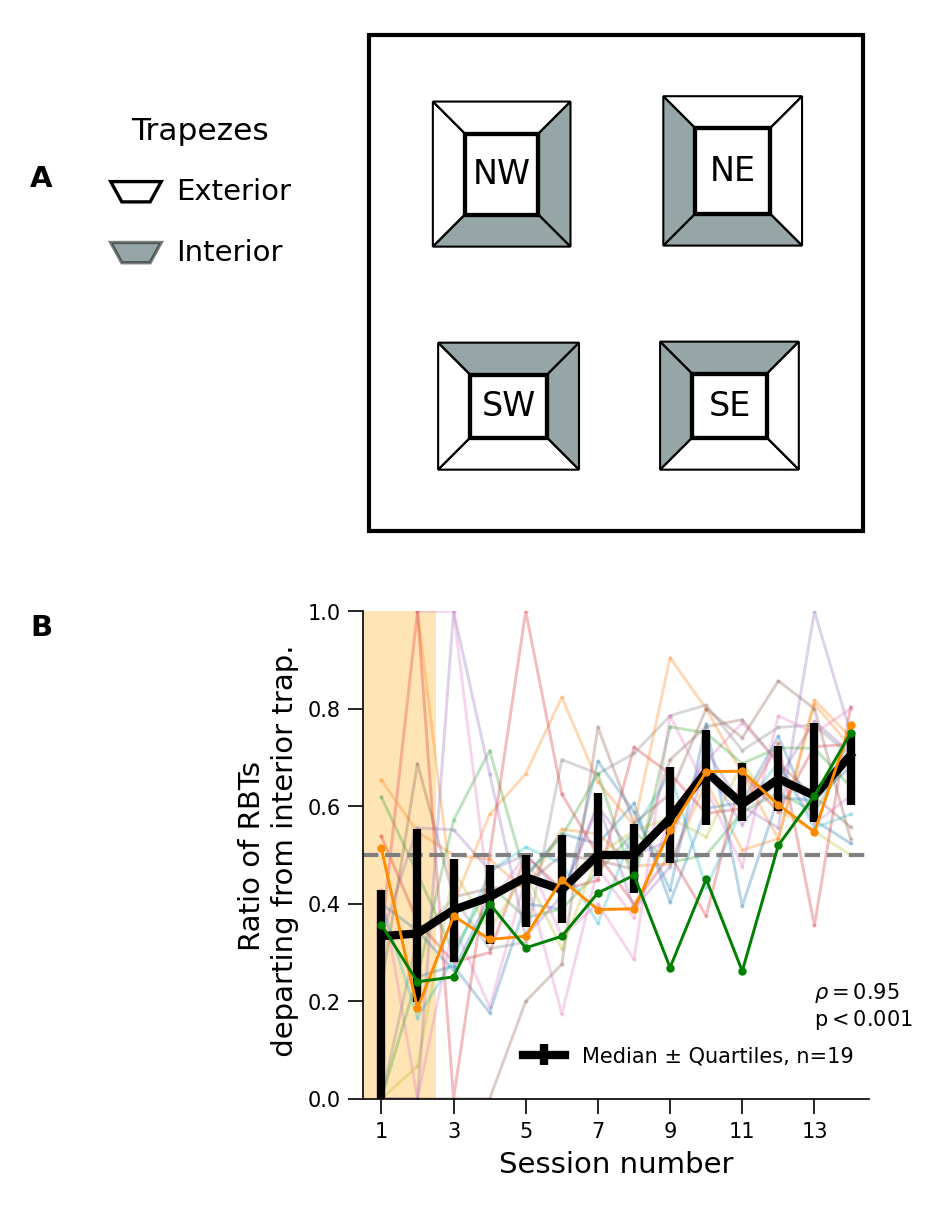

In [13]:
fig = plt.figure(figsize=(cm2inch(7), cm2inch(10)), dpi=300, constrained_layout=False, facecolor='w')

gs = fig.add_gridspec(
    2, 1,
    height_ratios=[1.5, 1.4],
    hspace=0.1
)

# Panel A
axA = fig.add_subplot(gs[0, 0])

highlight_trapeze_arena(axA, trapeze_width, highlight_trapezes, towers_coordinates_default, tower_label_size=8)

fig.text(-0.08, 0.85, 'A', fontsize=7, fontweight='bold')
add_trapeze_legend(axA, x0=-0.5, y0=0.7)

# Panel B
axB = fig.add_subplot(gs[1, 0])

plot_learning_curves(
    int_departure_trap_ratio_persession,
    axB,
    mice_to_highlight=illustration_mice,
    highlight_colors=illustration_colors,
    show_individual_mice=True,
    median_color='k',
    show_xlabel=True,
    xlim=xlim_stats,
    ylabel='QTs peak speed (cm/s)',
    main_line_label=f"Median ± Quartiles, n={len(mice_to_analyse)}",
    tick_interval=2,
    index_offset=session_index_offset,
    show_legend=True,
    legend_loc=(0.3, 0.05)
)

plot_shuffled_spearman_test_res(
    axB,
    (13, 0.15),
    int_departure_trap_ratio_persession,
    1000,
    'increasing',
    color='k',
    first_and_last_session_indexes=first_and_last_session_indexes_stats
)

axB.set_ylabel('Ratio of RBTs\n departing from interior trap.')
axB.set_xlabel('Session number')
axB.set_ylim([0, 1])
axB.axhline(0.5, 0, 20, color='grey', linestyle='--')
fig.text(-0.08, 0.47, 'B', fontsize=7, fontweight='bold')

fig.savefig("FigureS03.png", dpi=300, bbox_inches="tight", pad_inches=0.08)
fig.savefig("FigureS03.pdf", format="pdf", bbox_inches='tight', dpi=300)
plt.show()
